##### Feladat (Példatár 1.16)

Mekkora lehet a $P$ terhelés nagysága, ha az AC keresztmetszetben a hajlításból származó normálfeszültségre $\sigma_\mathrm{meg}= 200 ~\mathrm{MPa}$ a megengedhető érték? A hajlítás tengelyére a keresztmetszet másodrendű nyomatéka $I = 332.03125 ~\mathrm{cm}^4$, a keresztmetszet területe $A = 3750 ~\mathrm{mm}^2$.

<img src="img/01.jpg" alt="Feladat" width=400px>

##### Csomagok importálása

In [1]:
import numpy as np # Numerikus számítások
import matplotlib.pyplot as plt # Ábrázolás
plt.rcParams['mathtext.fontset'] = 'cm' # Betűtípus az ábrákon
plt.rcParams['font.family'] = 'serif' # Betűtípus az ábrákon
plt.rcParams['font.serif'] = ['cmr10'] # Betűtípus az ábrákon
plt.rcParams['axes.formatter.use_mathtext'] = True # Betűtípus az ábrákon
plt.rcParams['axes.unicode_minus'] = False # Betűtípus az ábrákon
from IPython.display import display, Math, Latex # Szép kimenet Jupyter notebookban
import sympy as sp # Szimbólikus számítások
from sympy import latex # Szép kimenet Jupyter notebookban
sp.init_printing() # Szép kimenet Jupyter notebookban

##### Adatok

In [2]:
A_data = 3750 # mm^2
I_data = 332.03125 # cm^4
sigma_meg_data = 200 # MPa
h_data = 100 # mm
R_data = 337.5 # mm
L_data = 600 # mm

# Átváltás N, mm, MPa rendszerbe
I_data = I_data * 10**4 # Nmm

In [3]:
A, I, sigma_meg, h, R, L, I = sp.symbols(r'A, I, \sigma_meg, h, R, L, I')

In [4]:
data = [(A, A_data),
        (I, I_data),
        (sigma_meg, sigma_meg_data),
        (h, h_data),
        (R, R_data),
        (L, L_data)]

##### Görbületi sugár és a görbületi sugár irányába eső legnagyobb méret hányadosa

In [5]:
ratio = (R / h).subs(data)
display(Math(rf'\frac{{R}}{{h}} = {latex(ratio)} \quad \longrightarrow \quad \mathrm{{Grashof-képlet}} ~ I_0 \approx I_x ~ \mathrm{{használatával}}'))

<IPython.core.display.Math object>

##### Hajlítónyomaték A-C keresztmetszetben

In [6]:
P = sp.Symbol('P', nonzero=True, positive=True, real=True)

#  Negatív előjel, mivel a rúd görbületét csökkenti
Mh = -L*P

##### Grashof-képlet

In [7]:
def sigma(y):
    return Mh/(R*A) + Mh/I * y * R/(R+y)

y = sp.Symbol('y')

display(Math(rf'\sigma_{{z}}(y) = {latex(sigma(y))}'))

display(Latex('Behelyettesítve:'))

display(Math(rf'\sigma_{{z}}(y) = {latex(sigma(y).subs(data).evalf(4))}'))

<IPython.core.display.Math object>

<IPython.core.display.Latex object>

<IPython.core.display.Math object>

##### Értéke a nevezetes pontokban

In [8]:
# A pont
y_A = -37.5 # mm

sigma_A = sigma(y_A).subs(data).evalf(6)
display(Math(rf'\sigma_{{z}}(y_A) = {latex(sigma_A)}'))

# Súlypont (S)
y_S = 0 # mm

sigma_S = sigma(y_S).subs(data).evalf(6)
display(Math(rf'\sigma_{{z}}(y_S) = {latex(sigma_S)}'))

# C pont
y_C = 62.5 # mm

sigma_C = sigma(y_C).subs(data).evalf(6)
display(Math(rf'\sigma_{{z}}(y_C) = {latex(sigma_C)}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

##### Normálfeszültség maximális értéke

In [9]:
sigma_max = sp.Max(sp.Abs(sigma_A), sp.Abs(sigma_S), sp.Abs(sigma_C))
display(Math(rf'\sigma_{{max}} = {latex(sigma_max)}'))

<IPython.core.display.Math object>

##### Határesetben egyenlő a megengedhető feszültséggel

In [10]:
eq = sigma_max - sigma_meg

sol = sp.solve(eq, P)
Psol = sol[0].subs(data)
display(Math(rf'P = {latex(round(Psol,2))} ~ \mathrm{{N}}'))

<IPython.core.display.Math object>

##### Normálfeszültség eloszlása

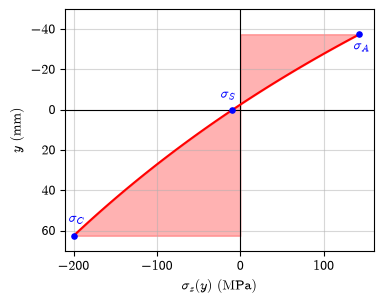

In [11]:
sigma_sym = sigma(y).subs(data).subs(P,Psol)

sigma_num = sp.lambdify(y, sigma_sym)

y_vals = np.linspace(y_A, y_C)
sigma_vals = sigma_num(y_vals)

plt.figure(figsize=(10/2.54, 8/2.54))
plt.plot(sigma_vals, y_vals, color='red', zorder=5)
plt.fill_betweenx(y_vals, sigma_vals, 0, color='red', alpha=0.3)
plt.scatter(float(sigma_A.subs(P,Psol)), float(y_A), color='blue', s=14, zorder=10)
plt.text(float(sigma_A.subs(P,Psol))*0.95, float(y_A)*0.8, r'$\sigma_A$', color='blue')
plt.scatter(float(sigma_S.subs(P,Psol)), float(y_S), color='blue', s=14, zorder=10)
plt.text(float(sigma_S.subs(P,Psol))*2.5, float(y_S)-6, r'$\sigma_S$', color='blue')
plt.scatter(float(sigma_C.subs(P,Psol)), float(y_C), color='blue', s=14, zorder=10)
plt.text(float(sigma_C.subs(P,Psol))*1.03, float(y_C)*0.89, r'$\sigma_C$', color='blue')
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel(r'$\sigma_z(y) ~ \mathrm{(MPa)}$')
plt.ylabel(r'$y ~ \mathrm{(mm)}$')
plt.grid(True, alpha=0.5)
plt.xlim(-210, 160)
plt.ylim(-50, 70)
plt.tight_layout()
plt.gca().invert_yaxis()
plt.savefig('normalfeszultseg_eloszlas.pdf')
plt.show()